# 딥러닝 라이브러리 2가지
## 텐서플로우(google) - 산업용
* 이미지 관련 라이브러리
* keras를 이용해 코딩이 쉬움
* 순차적, 함수적, 클래스

## 파이토치(meta) - 연구용
* 자연어 관련 라이브러리
* 허깅페이스, 랭체인
* 클래스
* 학습의 모든 과정을 커스텀화 할 수 있음

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ablearn/main/Taitanic_train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [4]:
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']]
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S


In [5]:
data['family'] = data['SibSp'] + data['Parch']
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,family
0,0,3,male,22.0,1,0,S,1
1,1,1,female,38.0,1,0,C,1
2,1,3,female,26.0,0,0,S,0
3,1,1,female,35.0,1,0,S,1
4,0,3,male,35.0,0,0,S,0


In [7]:
data = data.drop(['SibSp', 'Parch'], axis=1)
data

,Survived,Pclass,Sex,Age,Embarked,family
0,0,3,male,22.0,S,1
1,1,1,female,38.0,C,1
2,1,3,female,26.0,S,0
3,1,1,female,35.0,S,1
4,0,3,male,35.0,S,0
...,...,...,...,...,...,...
886,0,2,male,27.0,S,0
887,1,1,female,19.0,S,0
888,0,3,female,NaN,S,3
889,1,1,male,26.0,C,0


In [8]:
X = data.drop('Survived', axis=1)
y = data['Survived']

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [11]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 623 entries, 748 to 136
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    623 non-null    int64  
 1   Sex       623 non-null    str    
 2   Age       504 non-null    float64
 3   Embarked  621 non-null    str    
 4   family    623 non-null    int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 29.2 KB


# 딥러닝시에도 데이터 스케일을 맞춰 주어야 함
* MinMaxScaler를 주로 사용, StandardScaler도 사용, 이상값이 많은 경우 RobustScaler사용
* 이진분류: MinMax
* 연속값예측: Standard

In [12]:
X_train.columns

Index(['Pclass', 'Sex', 'Age', 'Embarked', 'family'], dtype='str')

In [13]:
num_cols = ['Age', 'family']
cat_cols = ['Pclass', 'Sex', 'Embarked']

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [16]:
num_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('mmx', MinMaxScaler())
])

cat_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

prep = ColumnTransformer(transformers=[
    ('num_cols', num_pipe, num_cols),
    ('cat_cols', cat_pipe, cat_cols)
], remainder='drop')

X_train_ppd = prep.fit_transform(X_train)
X_test_ppd = prep.transform(X_test)

# Tensorflow Sequential API를 사용한 순차적 모델 생성 및 분석

* Sequential: 인공신경망을 순차적으로 작성할 때 사용
* Dense: 층, 레이어 , 입력층, 은닉층, 출력층


In [18]:
import keras
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.layers import Dense

* 입력층은 반드시 독립변수의수(input_dim)를 정확히 지정
* 신경망 모델의 은닉층은 2~3개 정도로 한다.
* Dense의 노드수는 2의 배수의 지정 2 4 8 16 256
* Dense의 노드는 큰 수에서 작은 수로 줄여나간다.
* 은닉층의 활성화 함수: Relu
* 출력층은 이진분류일 경우 sigmoid, 다중분류일 경우 softmax
* 회귀분석일 경우(종속변수가 연속형(수치형)인 경우) 출력층에 활성화 함수 없이 노드를 1로 지정

In [24]:
# 독립변수 수 계산
X_train_ppd.shape[1]

7

In [23]:
# # 옛날 버전 코드
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense

# model = Sequential()

# model.add(Dense(64,
#                 activation='relu',
#                 input_dim=X_train_ppd.shape[1]))  # 입력층

# model.add(Dense(32, activation='relu'))  # 은닉층
# model.add(Dense(16, activation='relu'))  # 은닉층

# model.add(Dense(1, activation='sigmoid'))  # 출력층

In [42]:
# keras 3.0 기준 신경망 모델 정의
model = Sequential()
model.add(Input(shape=(X_train_ppd.shape[1],)))  # 입력층
model.add(Dense(64, activation='relu')) # 은닉층
model.add(Dense(32, activation='relu')) # 은닉층
model.add(Dense(16, activation='relu')) # 은닉층
model.add(Dense(1, activation='sigmoid')) # 출력층, 이진분류이므로 sigmoid

In [43]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

#  모델의 파라미터 세팅 model.compile()
* loss: 오차 계산 지표
  * 이진분류: binary_crossentropy
  * 다중분류: categorical_crossentropy - y가 one-hot encoding
  * 다중분류2: sparse_categorical_crossentropy - y가 label encoding
  * 연속형데이터(회귀분석): mse
* optimizer: learning_rate
  * adam을 가장 많이 사용
* metrics: 평가지표 accuracy

In [44]:
# pd.get_dummies(y_train)

In [45]:
# y_train

In [46]:
# 모델의 파라미터 세팅
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


# 모델 훈련 model.fit(X_train, y_train)
* epochs: 전체 데이터를 한 번 훈련하는 주기, 10-100 사이
* batch_size: 전체 데이터를 쪼개서 훈련, 데이터의 묶음, 메모리에 맞춰서 크기 조절(2의 배수) 32, 64로 쪼개서 넣는 것 추천
* validation_data: 검증 데이터로 모델 검증 실시

In [47]:
history = model.fit(X_train_ppd, y_train, epochs=300, batch_size=16,
                   validation_data=(X_test_ppd, y_test))

Epoch 1/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.6196 - loss: 0.6107 - val_accuracy: 0.6157 - val_loss: 0.5720
Epoch 2/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7352 - loss: 0.5501 - val_accuracy: 0.8172 - val_loss: 0.5381
Epoch 3/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7801 - loss: 0.5272 - val_accuracy: 0.7761 - val_loss: 0.5343
Epoch 4/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8042 - loss: 0.5080 - val_accuracy: 0.8172 - val_loss: 0.5008
Epoch 5/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8122 - loss: 0.4909 - val_accuracy: 0.8172 - val_loss: 0.4818
Epoch 6/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8090 - loss: 0.4720 - val_accuracy: 0.8172 - val_loss: 0.4655
Epoch 7/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8026 - loss: 0.4662 - val_accuracy: 0.8172 - val_loss: 0.4569
Epoch 8/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8090 - loss: 0.4524 - val_accuracy: 0.8172 - 

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8283 - loss: 0.4044 - val_accuracy: 0.7985 - val_loss: 0.4227
Epoch 52/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8331 - loss: 0.3970 - val_accuracy: 0.8022 - val_loss: 0.4173
Epoch 53/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8395 - loss: 0.3973 - val_accuracy: 0.8060 - val_loss: 0.4194
Epoch 54/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8331 - loss: 0.3989 - val_accuracy: 0.7873 - val_loss: 0.4244
Epoch 55/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8331 - loss: 0.3990 - val_accuracy: 0.8097 - val_loss: 0.4163
Epoch 56/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8363 - loss: 0.4008 - val_accuracy: 0.8134 - val_loss: 0.4161
Epoch 57/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8331 - loss: 0.3998 - val_accuracy: 0.7948 - val_loss: 0.4259
Epoch 58/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8266 - loss: 0.3991 - val_accuracy: 0.8097 - val_l

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8266 - loss: 0.3874 - val_accuracy: 0.7873 - val_loss: 0.4261
Epoch 102/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8459 - loss: 0.3825 - val_accuracy: 0.8097 - val_loss: 0.4195
Epoch 103/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8250 - loss: 0.3869 - val_accuracy: 0.7873 - val_loss: 0.4224
Epoch 104/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8315 - loss: 0.3789 - val_accuracy: 0.7724 - val_loss: 0.4448
Epoch 105/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8347 - loss: 0.3858 - val_accuracy: 0.7985 - val_loss: 0.4230
Epoch 106/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8331 - loss: 0.3841 - val_accuracy: 0.7985 - val_loss: 0.4237
Epoch 107/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8379 - loss: 0.3804 - val_accuracy: 0.7910 - val_loss: 0.4257
Epoch 108/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8411 - loss: 0.3817 - val_accuracy: 0.8022 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8443 - loss: 0.3642 - val_accuracy: 0.7948 - val_loss: 0.4362
Epoch 152/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8475 - loss: 0.3649 - val_accuracy: 0.8134 - val_loss: 0.4357
Epoch 153/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8523 - loss: 0.3679 - val_accuracy: 0.8022 - val_loss: 0.4369
Epoch 154/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8475 - loss: 0.3646 - val_accuracy: 0.8097 - val_loss: 0.4339
Epoch 155/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8475 - loss: 0.3652 - val_accuracy: 0.8022 - val_loss: 0.4332
Epoch 156/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8443 - loss: 0.3667 - val_accuracy: 0.8097 - val_loss: 0.4333
Epoch 157/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8427 - loss: 0.3653 - val_accuracy: 0.8060 - val_loss: 0.4358
Epoch 158/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8411 - loss: 0.3667 - val_accuracy: 0.8134 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8459 - loss: 0.3560 - val_accuracy: 0.8060 - val_loss: 0.4517
Epoch 202/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8555 - loss: 0.3545 - val_accuracy: 0.8134 - val_loss: 0.4535
Epoch 203/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8523 - loss: 0.3558 - val_accuracy: 0.7948 - val_loss: 0.4691
Epoch 204/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8523 - loss: 0.3554 - val_accuracy: 0.8172 - val_loss: 0.4564
Epoch 205/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8507 - loss: 0.3572 - val_accuracy: 0.8134 - val_loss: 0.4579
Epoch 206/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8539 - loss: 0.3566 - val_accuracy: 0.8060 - val_loss: 0.4529
Epoch 207/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8459 - loss: 0.3541 - val_accuracy: 0.8172 - val_loss: 0.4557
Epoch 208/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8475 - loss: 0.3547 - val_accuracy: 0.8097 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8443 - loss: 0.3521 - val_accuracy: 0.8097 - val_loss: 0.4807
Epoch 252/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8539 - loss: 0.3457 - val_accuracy: 0.8172 - val_loss: 0.4863
Epoch 253/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8539 - loss: 0.3431 - val_accuracy: 0.7985 - val_loss: 0.4920
Epoch 254/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8523 - loss: 0.3427 - val_accuracy: 0.8134 - val_loss: 0.4874
Epoch 255/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8427 - loss: 0.3470 - val_accuracy: 0.8209 - val_loss: 0.4856
Epoch 256/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8523 - loss: 0.3466 - val_accuracy: 0.7836 - val_loss: 0.4957
Epoch 257/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8636 - loss: 0.3425 - val_accuracy: 0.8134 - val_loss: 0.4910
Epoch 258/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8491 - loss: 0.3467 - val_accuracy: 0.7724 -

# 딥러닝 모델 성능 평가
* 딥러닝에서 모델의 성능을 평가하는 지표는 loss
* 보통 loss가 낮으면 accuracy가 올라가지만 비례하지 않을 때도 있음.
* accuracy와 loss 간의 차이가 있을 때 loss가 낮은 모델이 우수한 모델

In [48]:
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.619583,0.610732,0.615672,0.571965
1,0.735152,0.550076,0.817164,0.538141
2,0.780096,0.527195,0.776119,0.534253
3,0.804173,0.507981,0.817164,0.500776
4,0.812199,0.490853,0.817164,0.481788
...,...,...,...,...
295,0.853933,0.337475,0.817164,0.501347
296,0.857143,0.335477,0.764925,0.535807
297,0.852327,0.337395,0.791045,0.540767
298,0.858748,0.332140,0.802239,0.523978


# 훈련 결과 시각화

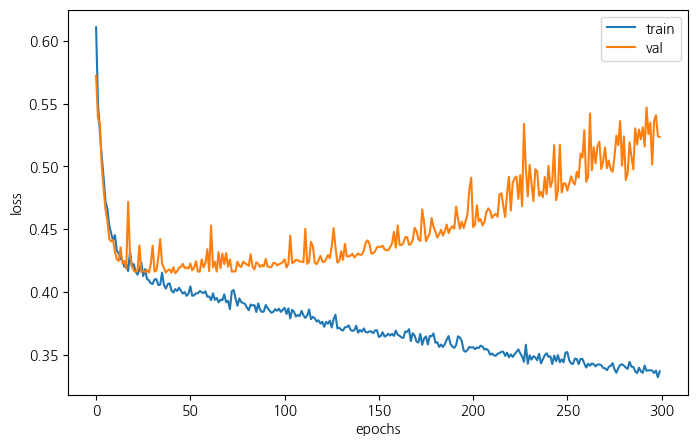

In [49]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# 모델의 예측 값 출력

In [50]:
pred = model.predict(X_test_ppd)
pred

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


array([[2.59126872e-01],
       [9.14621428e-02],
       [7.57230744e-02],
       [1.17643557e-01],
       [3.88077088e-02],
       [4.06131536e-01],
       [8.62915292e-02],
       [9.99991417e-01],
       [1.29375488e-01],
       [9.99604583e-01],
       [7.73615539e-01],
       [9.99840498e-01],
       [2.77081937e-01],
       [2.60951757e-01],
       [9.81549680e-01],
       [6.27485037e-01],
       [7.57230744e-02],
       [3.68044347e-01],
       [9.58873630e-01],
       [2.15157479e-01],
       [6.74261572e-03],
       [6.55452022e-03],
       [4.43330258e-01],
       [1.17643557e-01],
       [6.35405421e-01],
       [4.93404418e-02],
       [9.99707997e-01],
       [2.39409193e-01],
       [1.88608223e-03],
       [2.42354069e-02],
       [8.58336389e-01],
       [9.63939130e-01],
       [7.57230744e-02],
       [6.85709834e-01],
       [9.98494983e-01],
       [3.93792003e-01],
       [7.57230744e-02],
       [4.16140584e-03],
       [7.57230744e-02],
       [2.68407762e-01],


In [53]:
result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result['pred'] =  result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
result

,y_test,pred
625,0,0
566,0,0
459,0,0
804,1,0
338,1,0
...,...,...
184,1,1
607,1,0
624,0,0
103,0,0


# Functional API를 이용한 함수형 모델
* Sequential API는 단순히 층을 여러 개 쌓는 형태라 복잡한 모델 생성에 한계가 있음.
* Functional  API는 입력층과 출력층을 사용자가 직접 정의 가능
* 다중입력(Multi-input), 다중출력(Multi-output)등 복잡한 모델을 정의 할 수 있음.
* Input(shape=(독립변수 수))로 입력층 정의
* 이전 층을 다음 층의 입력으로 사용
* model()에 입력과 출력을 정의

In [54]:
from keras.layers import Input, Dense
from keras.models import Model

In [ ]:
# # 신경망 모델 정의 kearas 3.0, tensorflow 2.19 기준
# model = Sequential()
# model.add(Input(shape=(X_train_ppd.shape[1],))) # 입력층
# model.add(Dense(64, activation='relu')) # 은닉층
# model.add(Dense(32, activation='relu')) # 은닉층
# model.add(Dense(16, activation='relu')) # 은닉층
# model.add(Dense(1, activation='sigmoid')) # 출력층, 이진분류이므로 sigmoid

In [55]:
# 입력층
inputs = Input(shape=(X_test_ppd.shape[1],))

# 은닉층
x = Dense(64, activation='relu')(inputs)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)

# 출력층
outputs = Dense(1, activation='sigmoid')(x)

# 모델 정의
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
from sklearn.metrics import classification_report

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.6164 - loss: 0.6349 - val_accuracy: 0.6343 - val_loss: 0.5938
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7416 - loss: 0.5561 - val_accuracy: 0.8097 - val_loss: 0.5237
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8042 - loss: 0.5067 - val_accuracy: 0.8097 - val_loss: 0.4906
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8042 - loss: 0.4786 - val_accuracy: 0.7948 - val_loss: 0.4704
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8074 - loss: 0.4621 - val_accuracy: 0.7948 - val_loss: 0.4583
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8058 - loss: 0.4517 - val_accuracy: 0.8172 - val_loss: 0.4442
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7897 - loss: 0.4498 - val_accuracy: 0.8172 - val_loss: 0.4364
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8074 - loss: 0.4430 - val_accuracy: 0.7948 - 

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8379 - loss: 0.3952 - val_accuracy: 0.7910 - val_loss: 0.4319
Epoch 52/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8379 - loss: 0.3949 - val_accuracy: 0.8209 - val_loss: 0.4186
Epoch 53/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8395 - loss: 0.3944 - val_accuracy: 0.8060 - val_loss: 0.4178
Epoch 54/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8347 - loss: 0.3967 - val_accuracy: 0.8172 - val_loss: 0.4171
Epoch 55/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8347 - loss: 0.3957 - val_accuracy: 0.8209 - val_loss: 0.4170
Epoch 56/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8347 - loss: 0.3957 - val_accuracy: 0.7910 - val_loss: 0.4244
Epoch 57/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8315 - loss: 0.3929 - val_accuracy: 0.8246 - val_loss: 0.4205
Epoch 58/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8363 - loss: 0.3954 - val_accuracy: 0.8358 - val_lo

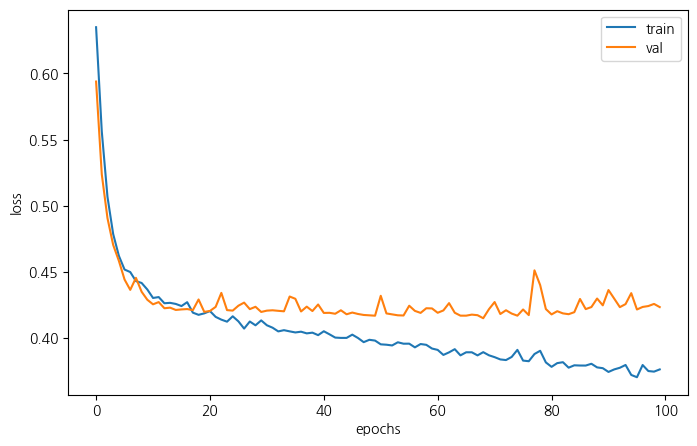

              precision    recall  f1-score   support

           0       0.81      0.93      0.86       165
           1       0.85      0.64      0.73       103

    accuracy                           0.82       268
   macro avg       0.83      0.78      0.80       268
weighted avg       0.82      0.82      0.81       268



In [57]:
# 모델의 파라미터 세팅
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train_ppd, y_train, epochs=100, batch_size=16,
                   validation_data=(X_test_ppd, y_test))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()
pred = model.predict(X_test_ppd)
pred
result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result['pred'] =  result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
print(classification_report(result['y_test'], result['pred']))

# class형으로 만들기 (Model Subclass API)
* class 형태의 모델 정의 방법
* keras의 Model을 상속받아 작성

In [ ]:
# # 입력층
# inputs = Input(shape=(X_test_ppd.shape[1],))

# # 은닉층
# x = Dense(64, activation='relu')(inputs)
# x = Dense(32, activation='relu')(x)
# x = Dense(16, activation='relu')(x)

# # 출력층
# outputs = Dense(1, activation='sigmoid')(x)

# # 모델 정의
# model = Model(inputs=inputs, outputs=outputs)
# model.summary()

In [61]:
class Titanic(Model):
    def __init__(self):
        super().__init__()  # 입력층
        self.dense1 = Dense(128, activation='relu') #은닉층
        self.dense2 = Dense(64, activation='relu') #은닉층
        self.dense3 = Dense(32, activation='relu') #은닉층
        self.dense4 = Dense(16, activation='relu') #은닉층
        self.outputs= Dense(1, activation='sigmoid') # 출력층
    
    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        return self.outputs(x)
    
        

In [62]:
model = Titanic()
print(model.summary())

Model: "titanic_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.7014 - loss: 0.5969 - val_accuracy: 0.8097 - val_loss: 0.5409
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7913 - loss: 0.5071 - val_accuracy: 0.7985 - val_loss: 0.4809
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7929 - loss: 0.4725 - val_accuracy: 0.8097 - val_loss: 0.4812
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7994 - loss: 0.4573 - val_accuracy: 0.7948 - val_loss: 0.4481
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8042 - loss: 0.4475 - val_accuracy: 0.8172 - val_loss: 0.4363
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8090 - loss: 0.4374 - val_accuracy: 0.8172 - val_loss: 0.4350
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7945 - loss: 0.4410 - val_accuracy: 0.8209 - val_loss: 0.4264
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8250 - loss: 0.4288 - val_accuracy: 0.8134 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8266 - loss: 0.3799 - val_accuracy: 0.7799 - val_loss: 0.4611
Epoch 52/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8331 - loss: 0.3897 - val_accuracy: 0.8060 - val_loss: 0.4488
Epoch 53/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8315 - loss: 0.3806 - val_accuracy: 0.7985 - val_loss: 0.4437
Epoch 54/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8379 - loss: 0.3792 - val_accuracy: 0.7985 - val_loss: 0.4460
Epoch 55/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8347 - loss: 0.3817 - val_accuracy: 0.8134 - val_loss: 0.4361
Epoch 56/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8411 - loss: 0.3794 - val_accuracy: 0.7910 - val_loss: 0.4477
Epoch 57/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8379 - loss: 0.3777 - val_accuracy: 0.7910 - val_loss: 0.4438
Epoch 58/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8363 - loss: 0.3803 - val_accuracy: 0.8097 - val_lo

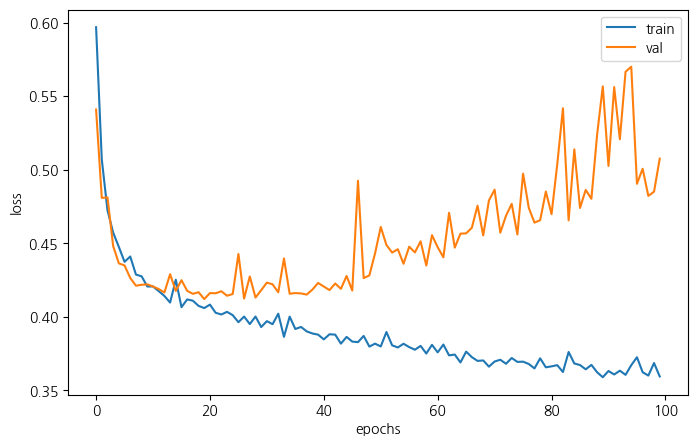

2026-03-18 11:36:26.135144: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-18 11:36:26.980462: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_20', 100 bytes spill stores, 100 bytes spill loads



9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       165
           1       0.78      0.69      0.73       103

    accuracy                           0.81       268
   macro avg       0.80      0.78      0.79       268
weighted avg       0.80      0.81      0.80       268



In [63]:
# 모델의 파라미터 세팅
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train_ppd, y_train, epochs=100, batch_size=16,
                   validation_data=(X_test_ppd, y_test))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

pred = model.predict(X_test_ppd)
pred
result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result['pred'] =  result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
print(classification_report(result['y_test'], result['pred']))